In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Load Sniff Locking and Spatial Information CSVs

In [2]:
sniff_path = 'E:/cbm-odor/sniff/sniff_locking.csv'
space_path = 'E:/cbm-odor/sniff/spatial_info.csv'
space_data = pd.read_csv(space_path)
sniff_lock_data = pd.read_csv(sniff_path)
display(space_data.tail(5))
display(sniff_lock_data.tail(5))

,mouse,session,region,cluster,group,n_spikes,n_spikes_tracked,n_bins_visited,si_bits_per_spike,ssi,p_empirical,p_gaussian,null_mean_bits_per_spike,null_sd_bits_per_spike
4874,9009,x9,ob,9,mua,22062,21807,105,0.009058,5.177469,0.001,1.124584e-07,0.005160,0.000753
4875,9009,x9,ob,10,mua,18876,18627,105,0.013475,7.218037,0.000,2.636780e-13,0.006146,0.001015
4876,9009,x9,ob,16,mua,56667,56020,105,0.005576,8.462854,0.000,0.000000e+00,0.002324,0.000384
4877,9009,x9,ob,18,mua,44116,43543,105,0.004192,0.509667,0.246,3.051425e-01,0.003785,0.000799
4878,9009,x9,ob,19,mua,38760,38322,105,0.005727,2.802560,0.008,2.534938e-03,0.003813,0.000683


,mouse,session,region,cluster,group,n_spikes,n_spikes_in_window,n_sniffs,rate_in_window_hz,info_bits_per_spike,info_bits_per_s,info_corrected_bits_per_spike,info_corrected_bits_per_s,info_z,info_p,shuffle_mean_bits_per_spike,shuffle_sd_bits_per_spike,peak_latency_ms,peak_rate_hz
4874,9009,x9,ob,9,mua,22062,20876,17576,8.553645,0.227779,1.948344,0.223382,1.910730,341.276491,0.001996,0.004398,0.000655,100.0,16.203181
4875,9009,x9,ob,10,mua,18876,17846,17576,7.312145,0.203396,1.487264,0.200099,1.463152,313.432975,0.001996,0.003298,0.000638,74.0,13.808923
4876,9009,x9,ob,16,mua,56667,52332,17576,21.442295,0.029877,0.640625,0.028198,0.604621,114.726597,0.001996,0.001679,0.000246,136.0,28.363821
4877,9009,x9,ob,18,mua,44116,40338,17576,16.527923,0.021407,0.353813,0.020331,0.336037,96.012104,0.001996,0.001076,0.000212,128.0,21.677384
4878,9009,x9,ob,19,mua,38760,35716,17576,14.634124,0.029242,0.427930,0.027745,0.406020,100.612934,0.001996,0.001497,0.000276,70.0,19.107018


# Create Spatio-Temporal Information Index

In [11]:
keys = ['mouse', 'session', 'region', 'cluster']
st_info_df = sniff_lock_data[keys + ['group', 'n_spikes', 'peak_latency_ms', 'info_bits_per_spike', 'info_z', 'info_p']].merge(
    space_data[keys + ['si_bits_per_spike', 'ssi', 'p_empirical']],
    on=keys, how='inner', validate='one_to_one',
)

# Use shuffle-normalized z-scores (removes low-spike-count bias), then percentile-rank within region
# so the two measures share a scale and OB/HC differences don't dominate.
st_info_df['t_pct'] = st_info_df.groupby('region')['info_z'].rank(pct=True)
st_info_df['s_pct'] = st_info_df.groupby('region')['ssi'].rank(pct=True)

# min() is high only when BOTH are high, so neither dimension can carry the score alone
st_info_df['st_info_index'] = st_info_df[['t_pct', 's_pct']].min(axis=1)
st_info_df['st_imbalance'] = (st_info_df['t_pct'] - st_info_df['s_pct']).abs()
st_info_df['sig_both'] = (st_info_df['info_p'] < 0.05) & (st_info_df['p_empirical'] < 0.05)
display(st_info_df.head(5))

,mouse,session,region,cluster,group,n_spikes,peak_latency_ms,info_bits_per_spike,info_z,info_p,si_bits_per_spike,ssi,p_empirical,t_pct,s_pct,st_info_index,st_imbalance,sig_both
0,9000,o2,hc,0,mua,15869,46.0,0.002178,-0.711715,0.752495,0.015074,9.263842,0.00,0.154317,0.262262,0.154317,0.107945,False
1,9000,o2,hc,1,NaN,98878,248.0,0.000748,4.689366,0.001996,0.013868,45.720035,0.00,0.812712,0.913828,0.812712,0.101116,True
2,9000,o2,hc,2,NaN,5021,216.0,0.009869,-0.609903,0.724551,0.118514,1.666427,0.07,0.170292,0.042234,0.042234,0.128058,False
3,9000,o2,hc,3,NaN,30647,206.0,0.001536,0.925430,0.169661,0.012105,7.122462,0.00,0.444256,0.202997,0.202997,0.241258,False
4,9000,o2,hc,4,NaN,73950,52.0,0.000721,1.777962,0.055888,0.062884,42.778739,0.00,0.580218,0.897139,0.580218,0.316921,False


In [8]:
st_info_sorted = st_info_df[st_info_df['sig_both']].sort_values(by='st_info_index', ascending=False)
display(st_info_sorted.head(25))

,mouse,session,region,cluster,group,n_spikes,peak_latency_ms,info_bits_per_spike,info_z,info_p,si_bits_per_spike,ssi,p_empirical,t_pct,s_pct,st_info_index,st_imbalance,sig_both
3767,9008,t2,ob,7,mua,42066,84.0,0.599692,810.739878,0.001996,0.049094,58.945319,0.0,0.985545,0.997419,0.985545,0.011874,True
4606,9009,x2,ob,2,good,82570,104.0,0.344119,1251.204493,0.001996,0.027348,44.179282,0.0,0.997419,0.984512,0.984512,0.012907,True
3806,9008,t3,ob,6,good,43615,86.0,0.153279,725.918237,0.001996,0.020258,36.719021,0.0,0.979350,0.968508,0.968508,0.010842,True
356,9000,x2,hc,16,good,89929,58.0,0.002638,20.536667,0.001996,0.018671,104.663989,0.0,0.962950,0.993869,0.962950,0.030919,True
3765,9008,t2,ob,5,mua,35315,82.0,0.650248,721.471111,0.001996,0.036624,31.998142,0.0,0.978833,0.954569,0.954569,0.024264,True
3764,9008,t2,ob,4,mua,22312,80.0,0.711230,732.357891,0.001996,0.043894,31.551945,0.0,0.980382,0.953020,0.953020,0.027362,True
234,9000,x1,hc,9,good,96871,66.0,0.001809,16.863824,0.001996,0.021210,71.429028,0.0,0.951734,0.976158,0.951734,0.024425,True
3648,9007,x9,hc,16,good,122004,46.0,0.004264,15.002091,0.001996,0.039875,68.689589,0.0,0.944256,0.971730,0.944256,0.027475,True
1421,9003,x3,hc,12,mua,84662,200.0,0.013498,14.798156,0.001996,0.257563,62.331594,0.0,0.942216,0.964237,0.942216,0.022021,True
474,9000,x7,hc,12,mua,34313,42.0,0.018724,14.583439,0.001996,0.646215,75.709398,0.0,0.940857,0.979905,0.940857,0.039048,True


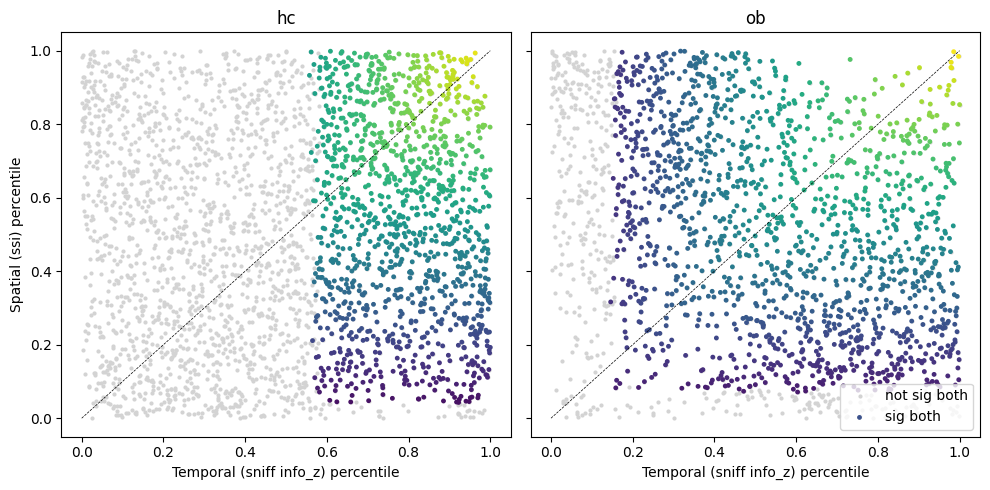

In [9]:
fig, axes = plt.subplots(1, st_info_df['region'].nunique(), figsize=(10, 5), sharex=True, sharey=True)
for ax, (region, df) in zip(np.atleast_1d(axes), st_info_df.groupby('region')):
    ax.scatter(df['t_pct'], df['s_pct'], s=4, c='lightgray', label='not sig both')
    sig = df[df['sig_both']]
    ax.scatter(sig['t_pct'], sig['s_pct'], s=6, c=sig['st_info_index'], cmap='viridis', vmin=0, vmax=1, label='sig both')
    ax.plot([0, 1], [0, 1], 'k--', lw=0.5)
    ax.set_title(region)
    ax.set_xlabel('Temporal (sniff info_z) percentile')
ax.legend(loc='lower right')
np.atleast_1d(axes)[0].set_ylabel('Spatial (ssi) percentile')
plt.tight_layout()
plt.show()

### Sniff and Spatial Units Separately

In [12]:
sl_sorted = sniff_lock_data.sort_values(by='info_bits_per_spike', ascending=False)
# Only take rows with 'x' in the session column
sl_sorted = sl_sorted[sl_sorted['session'].str.contains('x')]
display(sl_sorted.head(5))

,mouse,session,region,cluster,group,n_spikes,n_spikes_in_window,n_sniffs,rate_in_window_hz,info_bits_per_spike,info_bits_per_s,info_corrected_bits_per_spike,info_corrected_bits_per_s,info_z,info_p,shuffle_mean_bits_per_spike,shuffle_sd_bits_per_spike,peak_latency_ms,peak_rate_hz
1579,9003,x8,ob,11,good,68302,66187,17313,25.845483,0.514021,13.285127,0.512766,13.252674,1574.462316,0.001996,0.001256,0.000326,86.0,71.081303
4772,9009,x5,ob,2,mua,77746,74561,17197,31.352852,0.429062,13.452308,0.425149,13.329633,837.548517,0.001996,0.003913,0.000508,84.0,76.139234
4716,9009,x4,ob,2,mua,42845,40348,15019,17.734613,0.420865,7.463871,0.416344,7.383693,669.063101,0.001996,0.004521,0.000622,84.0,43.302915
4564,9009,x11,ob,5,mua,30414,29845,18527,11.889335,0.410017,4.874827,0.408382,4.855388,1187.691469,0.001996,0.001635,0.000344,90.0,34.897302
770,9002,x1,hc,5,good,124,108,17713,0.043862,0.394943,0.017323,0.029935,0.001313,0.484873,0.311377,0.365008,0.061737,58.0,0.166121


In [14]:
hc_sorted = sl_sorted[sl_sorted['region'].str.contains('hc')].sort_values(by='info_z', ascending=False)
hc_sorted.head(5)

,mouse,session,region,cluster,group,n_spikes,n_spikes_in_window,n_sniffs,rate_in_window_hz,info_bits_per_spike,info_bits_per_s,info_corrected_bits_per_spike,info_corrected_bits_per_s,info_z,info_p,shuffle_mean_bits_per_spike,shuffle_sd_bits_per_spike,peak_latency_ms,peak_rate_hz
2223,9005,x6,hc,6,good,155534,144973,18237,59.385447,0.014768,0.876977,0.013393,0.795344,124.073962,0.001996,0.001375,0.000108,2.0,78.757158
2986,9006,x4,hc,21,good,12725,11618,16631,4.813387,0.090603,0.436106,0.086942,0.418485,115.823029,0.001996,0.003661,0.000751,100.0,8.682225
3053,9006,x5,hc,9,good,10601,9583,16532,4.068522,0.068761,0.279757,0.064445,0.262196,75.609408,0.001996,0.004316,0.000852,112.0,6.170037
4680,9009,x4,hc,3,mua,15884,13489,15019,5.928973,0.046194,0.273882,0.042980,0.254828,66.054529,0.001996,0.003214,0.000651,60.0,11.828761
4713,9009,x4,hc,47,NaN,22695,19395,15019,8.524904,0.043400,0.369978,0.039689,0.338346,60.676875,0.001996,0.003711,0.000654,42.0,14.926543
